In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from analysis_utils import *

# Rescue Alus that are not actually truncated
This script will identify Alu-STRs that were originally not included in our full length analysis because we only passed a subsequence to cAlu due to repeatmasker annotation

In [2]:
def get_truncated_alus(calu_str):
    '''checks the calu string for large deletions on either the 3' or 5' end of the Alu
    and returns if the Alu is 3' truncated or 5' truncated (or both) (all of these are relative to the forward orientation)
    returns number of bases truncated on either end
    '''
    # split the output by |
    five_prime = calu_str.split("|")[0]
    three_prime = calu_str.split("|")[-1]

    # check if the three prime end is truncated ie is there both a d and a - in the string
    three_prime_truncated = 0
    if three_prime.count("d") > 0 and three_prime.count("-") > 0:
        start = int(three_prime.split("d")[1].split("-")[0])
        end = int(three_prime.split("d")[1].split("-")[1])
        three_prime_truncated = end - start

    # check if the five prime end is truncated ie is there both a d and a - in the string
    five_prime_truncated = 0
    if five_prime.count("d") > 0 and five_prime.count("-") > 0:
        start = int(five_prime.split("d")[1].split("-")[0])
        end = int(five_prime.split("d")[1].split("-")[1])
        five_prime_truncated = end - start

    return str(five_prime_truncated)+"_"+str(three_prime_truncated)
def determine_final_mei_coordinates(row):
    """
    Determine final MEI coordinates based on STR classification rules:
    1. External: Use coordinates of overlapping or closest MEI (upstream if tie)
    2. Non-MEI: Return "non_mei"
    3. Internal fully overlapped: Use MEI coordinates that overlap the STR
    4. Internal between fragments: Combine upstream start with downstream end
    """
    
    # Helper function to parse coordinates
    def parse_coords(coord_str):
        if pd.isna(coord_str) or coord_str == "NA":
            return None, None
        try:
            start, end = coord_str.split(":")
            return int(start), int(end)
        except:
            return None, None
    
    classification = row['STR_classification']
    
    # Case 1: Non-MEI STRs
    if classification == "non_mei":
        return "non_mei", "non_mei", "non_mei", "non_mei"
    
    # Parse upstream and downstream coordinates
    up_start, up_end = parse_coords(row['upstream_coords'])
    down_start, down_end = parse_coords(row['downstream_coords'])
    
    # Case 2: External STRs
    if row['internal_external'] == "external":
        # Priority order: overlapping > proximity, upstream > downstream if tie
        # But avoid NA values when non-NA values are available
        
        # Check for overlapping MEIs first (distance = 0)
        if row['upstream_distance'] == 0 and up_start is not None:  # Upstream overlap
            return up_start, up_end, row['upstream_ID'], row['upstream_family']
        elif row['downstream_distance'] == 0 and down_start is not None:  # Downstream overlap
            return down_start, down_end, row['downstream_ID'], row['downstream_family']
        
        # No overlap, choose closest available MEI
        # Convert distances to numeric, handling NA values
        up_dist = float('inf')
        down_dist = float('inf')
        
        if row['upstream_distance'] != "NA" and up_start is not None:
            try:
                up_dist = float(row['upstream_distance'])
            except:
                up_dist = float('inf')
        
        if row['downstream_distance'] != "NA" and down_start is not None:
            try:
                down_dist = float(row['downstream_distance'])
            except:
                down_dist = float('inf')
        
        # Choose the closest available MEI (upstream if tie)
        if up_dist <= down_dist and up_dist != float('inf'):
            return up_start, up_end, row['upstream_ID'], row['upstream_family']
        elif down_dist != float('inf'):
            return down_start, down_end, row['downstream_ID'], row['downstream_family']
        else:
            return "NA", "NA", "NA", "NA"
    
    # Case 3: Internal STRs
    elif row['internal_external'] == "internal":
        
        # Internal fully overlapped: use the MEI coordinates that overlap
        if classification == "internal_fully_overlapped":
            # Should be same coordinates upstream and downstream
            if up_start is not None:
                return up_start, up_end, row['upstream_ID'], row['upstream_family']
            elif down_start is not None:
                return down_start, down_end, row['downstream_ID'], row['downstream_family']
        
        # Internal between fragments: combine upstream start with downstream end
        elif classification == "internal_between_fragments":
            if up_start is not None and down_end is not None:
                # Use the same MEI ID (should be same for both fragments)
                mei_id = row['upstream_ID'] if row['upstream_ID'] != "NA" else row['downstream_ID']
                mei_family = row['upstream_family'] if row['upstream_family'] != "NA" else row['downstream_family']
                return up_start, down_end, mei_id, mei_family
            elif up_start is not None:  # Fallback to upstream only
                return up_start, up_end, row['upstream_ID'], row['upstream_family']
            elif down_start is not None:  # Fallback to downstream only
                return down_start, down_end, row['downstream_ID'], row['downstream_family']
        
        # Other internal types (internal_overlapped)
        else:
            if up_start is not None:
                return up_start, up_end, row['upstream_ID'], row['upstream_family']
            elif down_start is not None:
                return down_start, down_end, row['downstream_ID'], row['downstream_family']
    
    # Default case
    return "NA", "NA", "NA", "NA"



In [3]:
#read the original cAlu results to get "truncated" Alus
orientation_df = pd.read_csv("/data/projects/nanopore/RepeatExpansion/coordinates/repeatmasker_hg38_Alus_orientation.out", sep="\t")
orientation_df.columns = ["chrom", "start_mei", "end_mei","alu_subfamily","score", "orientation"]
# (2) load the output from calu
calu_df = pd.read_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/calu/MEI_STR_analysis/all_alu_hg38_seqs.parallel.out", sep="\t", header=None)
calu_df.columns = ["chrom", "start_mei", "end_mei","alu_family","alu_subfamily_calu", "num_family_changes","num_subfamily_changes","changes_str"]

# (3) merge on chr start end
all_calu_df = pd.merge(calu_df, orientation_df[["chrom","start_mei","end_mei","orientation","alu_subfamily"]], on=["chrom", "start_mei", "end_mei"], how="left")
print(all_calu_df.shape)
# get full length Alus
all_calu_df["trunctation"] = all_calu_df.changes_str.apply(get_truncated_alus)
all_calu_df[["five_prime_truncation","three_prime_truncation"]] = all_calu_df["trunctation"].str.split("_", expand=True)
all_calu_df["five_prime_truncation"] = all_calu_df["five_prime_truncation"].astype(int)
all_calu_df["three_prime_truncation"] = all_calu_df["three_prime_truncation"].astype(int)

all_calu_df["full_length"] = (all_calu_df["five_prime_truncation"].astype(int) + all_calu_df["three_prime_truncation"].astype(int)) < 14

(1238490, 10)


In [4]:
# add the MEI id from the repeatmasker tab file


In [5]:
repeatmasker_headers = [
    'SW_score',           # Column 0: Smith-Waterman score
    'perc_div',           # Column 1: % divergence 
    'perc_del',           # Column 2: % deletions
    'perc_ins',           # Column 3: % insertions
    'query_sequence',     # Column 4: query sequence (chromosome)
    'query_begin',        # Column 5: position in query begin
    'query_end',          # Column 6: position in query end
    'query_left',         # Column 7: bases in query sequence left of match
    'strand',             # Column 8: strand (+ or C for complement)
    'matching_repeat',    # Column 9: name of matching repeat
    'repeat_class_family', # Column 10: class/family of repeat
    'repeat_begin',       # Column 11: position in repeat begin
    'repeat_end',         # Column 12: position in repeat end  
    'repeat_left',        # Column 13: bases in repeat left of match
    'ID'                  # Column 14: ID number
]

# Read the file, skipping the first 2 header lines and using our standardized headers
repeatmasker_full = pd.read_csv("/data/projects/nanopore/RepeatExpansion/coordinates/repeatmasker_hg38.fa.out.tab", 
                                sep="\t", 
                                header=None, 
                                skiprows=2,  # Skip the 2-line header
                                names=repeatmasker_headers)

print(f"RepeatMasker file loaded with {len(repeatmasker_full):,} entries")
print("\nColumn names:")
for i, col in enumerate(repeatmasker_headers):
    print(f"  {i:2d}: {col}")

print(f"\nFirst few rows:")
repeatmasker_full.head()

RepeatMasker file loaded with 5,622,516 entries

Column names:
   0: SW_score
   1: perc_div
   2: perc_del
   3: perc_ins
   4: query_sequence
   5: query_begin
   6: query_end
   7: query_left
   8: strand
   9: matching_repeat
  10: repeat_class_family
  11: repeat_begin
  12: repeat_end
  13: repeat_left
  14: ID

First few rows:


,SW_score,perc_div,perc_del,perc_ins,query_sequence,query_begin,query_end,query_left,strand,matching_repeat,repeat_class_family,repeat_begin,repeat_end,repeat_left,ID
0,463,1.3,0.6,1.7,chr1,10001,10468,(248945954),+,(TAACCC)n,Simple_repeat,1,463,(0),1.0
1,4005,11.3,21.5,1.3,chr1,10469,11447,(248944975),C,TAR1,Satellite/telo,(399),1712,483,2.0
2,535,21.2,15.9,3.1,chr1,11485,11676,(248944746),C,L1MC5a,LINE/L1,(510),5667,5447,3.0
3,263,29.4,1.9,1.0,chr1,11678,11780,(248944642),C,MER5B,DNA/hAT-Charlie,(74),104,1,4.0
4,309,23.0,3.7,0.0,chr1,15265,15355,(248941067),C,MIR3,SINE/MIR,(119),143,49,5.0


Both sides of the interrupted Alus should be in cAlu regardless of if they are actually assigned to the STR so we should be able to get the total fragment lengths from them

In [6]:
# get the ID column from repeatmasker and add it by merging query_sequence query_begin query_end on all_calu_df chrom start_mei end_mei
all_calu_df = pd.merge(all_calu_df, repeatmasker_full[["query_sequence", "query_begin", "query_end", "ID"]],
                       left_on=["chrom", "start_mei", "end_mei"],
                       right_on=["query_sequence", "query_begin", "query_end"],
                       how="left")
all_calu_df.rename(columns={"ID":"MEI_ID"}, inplace=True)
all_calu_df

,chrom,start_mei,end_mei,alu_family,alu_subfamily_calu,num_family_changes,num_subfamily_changes,changes_str,orientation,alu_subfamily,trunctation,five_prime_truncation,three_prime_truncation,full_length,query_sequence,query_begin,query_end,MEI_ID
0,chr1,40629,40729,AluS,AluSz,12,12,d1-207|g215a|g238a|c239t|c241t|c255g|c261t|d26...,-,AluSx3,206_0,206,0,False,chr1,40629,40729,45.0
1,chr1,33466,33509,AluJ,AluJo,13,13,d1|g2a|g5a|g7a|c8t|c10t|g14t|g21a|t24c|g25a|g3...,+,Alu,0_237,0,237,False,chr1,33466,33509,32.0
2,chr1,54819,54938,AluJ,AluJo,32,32,c3t|g5a|c8t|g11a|g12a|c18t|a19g|c20t|g21c|a28t...,-,FLAM_A,0_162,0,162,False,chr1,54819,54938,65.0
3,chr1,108330,108564,AluJ,AluJo,58,58,d1|g5a|c8t|g11a|g21a|g34c|t40c|g41a|c48t|d54-8...,+,AluJb,0_0,0,0,True,chr1,108330,108564,138.0
4,chr1,35367,35493,AluJ,AluJo,20,20,d1|g5a|c8t|g11a|c20t|c22t|g25a|g34a|c48t|c53t|...,+,AluJr,0_154,0,154,False,chr1,35367,35493,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238485,chrY,57203561,57203838,AluS,AluSz,34,34,d1-15|c16t|c20t|c37t|c48t|c62t|g67c|a73c|g74a|...,+,AluSz,14_0,14,0,False,chrY,57203561,57203838,4691235.0
1238486,chrY,57200410,57200711,AluS,AluSz,45,45,d1|g5t|g9a|c10t|c20t|g42a|c48t|g54a|g55a|g58a|...,+,AluSz,0_0,0,0,True,chrY,57200410,57200711,4691229.0
1238487,chrY,57183018,57183316,AluS,AluSz,39,39,d1|c4t|c10t|g21a|t40a|c48t|g49t|c53t|c72t|g81a...,+,AluSx1,0_0,0,0,True,chrY,57183018,57183316,4691206.0
1238488,chrY,57200712,57201029,AluS,AluSg,39,38,d1|g5a|c8a|g11a|t17g|c20t|c22t|c53t|c57t|t61c|...,+,AluSg7,0_0,0,0,True,chrY,57200712,57201029,4691230.0


Most Alus are 1 or 2 parts

40159 duplicated MEI_IDs found


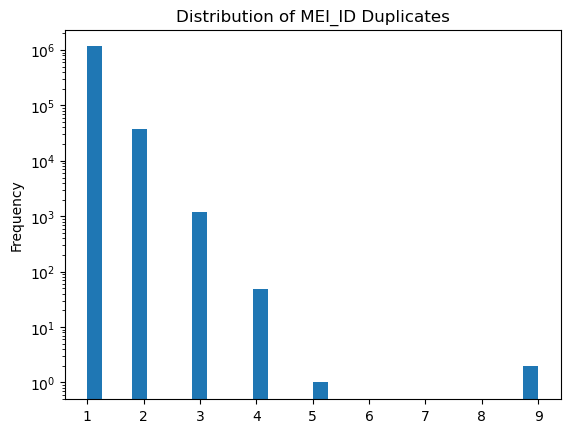

In [7]:
# how many of the Alus have duplicated MEI_ID?
print(f"{all_calu_df.MEI_ID.duplicated().sum()} duplicated MEI_IDs found")

# plot a histogram of the number of times each MEI_ID is duplicated
all_calu_df.MEI_ID.value_counts().plot(kind='hist', bins=30, title='Distribution of MEI_ID Duplicates')
plt.yscale('log')
plt.show()

In [8]:
# read our revised STR assignments
revised_labels= pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/get_flanking_repeats_mei_families/flanking_repeats_summary.tsv",sep="\t",header=0)
revised_labels.loc[revised_labels["STR_classification"] == "none", "STR_classification"] = "non_mei"
revised_labels["internal_external"] = np.where((revised_labels["STR_classification"].str.contains("internal")), "internal", "external")
revised_labels["internal_external"] = np.where(revised_labels["STR_classification"] == "non_mei", "non_mei", revised_labels["internal_external"])
revised_labels.internal_external.value_counts()
revised_labels

,STR_chr,STR_start,STR_end,STR_ID,upstream_coords,upstream_family,upstream_ID,upstream_distance,downstream_coords,downstream_family,downstream_ID,downstream_distance,STR_classification,internal_external
0,chr1,14068,14081,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
1,chr1,15810,15822,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
2,chr1,16618,16632,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
3,chr1,16715,16727,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
4,chr1,19174,19184,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430013,chrY,56694117,56694136,4542235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
2430014,chrY,56694220,56694236,4542236.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
2430015,chrY,56694332,56694350,4542237.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei
2430016,chrY,56694378,56694395,4542238.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei


In [9]:
# Apply the function to determine final MEI coordinates
print("Determining final MEI coordinates...")
coords_result = revised_labels.apply(determine_final_mei_coordinates, axis=1, result_type='expand')
revised_labels[['final_mei_start', 'final_mei_end', 'final_mei_id', 'final_mei_family']] = coords_result

# Display summary
print("\nFinal MEI coordinate assignment summary:")
print("=" * 50)

# Count by classification
# coord_summary = revised_labels.groupby('STR_classification').agg({
#     'final_mei_start': lambda x: sum(x != "NA" and x != "non_mei"),
#     'final_mei_id': lambda x: sum(x != "NA" and x != "non_mei")
# }).rename(columns={'final_mei_start': 'coords_assigned', 'final_mei_id': 'ids_assigned'})

# print(coord_summary)

print(f"\nTotal STRs with MEI coordinates assigned: {sum(revised_labels['final_mei_start'].isin(['NA', 'non_mei']) == False)}")
print(f"Total non-MEI STRs: {sum(revised_labels['final_mei_start'] == 'non_mei')}")
print(f"Total STRs without coordinates: {sum(revised_labels['final_mei_start'] == 'NA')}")

# Show family distribution
print(f"\nMEI family distribution:")
family_counts = revised_labels[revised_labels['final_mei_family'].notna() & 
                              (revised_labels['final_mei_family'] != 'NA') & 
                              (revised_labels['final_mei_family'] != 'non_mei')]['final_mei_family'].value_counts()
print(family_counts)

revised_labels.head()

Determining final MEI coordinates...

Final MEI coordinate assignment summary:

Total STRs with MEI coordinates assigned: 1241009
Total non-MEI STRs: 1189009
Total STRs without coordinates: 0

MEI family distribution:
final_mei_family
SINE/Alu          421033
LINE/L1           404141
LINE/L2           109976
SINE/MIR           98760
LTR/ERVL-MaLR      82171
LTR/ERV1           51770
LTR/ERVL           46134
LINE/CR1            8276
LTR/ERVK            4187
LTR/Gypsy           3109
LINE/RTE-X          2385
Retroposon/SVA      1977
LTR/Gypsy?          1353
LTR                 1325
LINE/RTE-BovB       1048
LTR?                1003
LTR/ERVL?            688
SINE/tRNA-RTE        531
LTR/ERV1?            303
SINE/5S-Deu-L2       291
SINE/tRNA            206
LINE/Dong-R4          87
.                     86
LINE/Penelope         74
LINE/L1-Tx1           40
SINE/tRNA-Deu         37
LINE/Jockey           18
Name: count, dtype: int64


,STR_chr,STR_start,STR_end,STR_ID,upstream_coords,upstream_family,upstream_ID,upstream_distance,downstream_coords,downstream_family,downstream_ID,downstream_distance,STR_classification,internal_external,final_mei_start,final_mei_end,final_mei_id,final_mei_family
0,chr1,14068,14081,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
1,chr1,15810,15822,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
2,chr1,16618,16632,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
3,chr1,16715,16727,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
4,chr1,19174,19184,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei


In [6]:
revised_labels[revised_labels.STR_classification != "none"]

,STR_chr,STR_start,STR_end,STR_ID,upstream_coords,upstream_family,upstream_ID,upstream_distance,downstream_coords,downstream_family,downstream_ID,downstream_distance,STR_classification
11,chr1,26931,26941,26.0,26791:27053,SINE/Alu,19.0,0.0,26791:27053,SINE/Alu,19.0,0.0,internal_fully_overlapped
12,chr1,27862,27872,27.0,27833:28014,SINE/MIR,21.0,0.0,27833:28014,SINE/MIR,21.0,0.0,internal_fully_overlapped
13,chr1,28245,28255,28.0,28151:28302,SINE/MIR,22.0,0.0,28151:28302,SINE/MIR,22.0,0.0,internal_fully_overlapped
17,chr1,30866,30892,34.0,30694:30848,LTR/ERVL-MaLR,26.0,19.0,NaN,NaN,NaN,NaN,external_upstream_proximity
19,chr1,30934,30948,36.0,NaN,NaN,NaN,NaN,30953:31131,LTR/ERVL-MaLR,26.0,6.0,external_downstream_proximity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429647,chrY,26629465,26629475,4541854.0,26629185:26629482,SINE/Alu,4690658.0,0.0,26629185:26629482,SINE/Alu,4690658.0,0.0,internal_fully_overlapped
2429648,chrY,26629761,26629771,4541855.0,26629705:26630365,LINE/L1,4690657.0,0.0,26629705:26630365,LINE/L1,4690657.0,0.0,internal_fully_overlapped
2429650,chrY,26634091,26634101,4541859.0,26633942:26634244,SINE/Alu,4690664.0,0.0,26633942:26634244,SINE/Alu,4690664.0,0.0,internal_fully_overlapped
2429653,chrY,26636524,26636535,4541864.0,26636475:26636675,SINE/MIR,4690666.0,0.0,26636475:26636675,SINE/MIR,4690666.0,0.0,internal_fully_overlapped


In [8]:
# get the matching_repeat, strand, perc_div, and ID columns and merge with revised_labels on ID and final_mei_id
mei_rows = revised_labels[revised_labels['final_mei_id'] != 'non_mei']
non_mei_rows = revised_labels[revised_labels['final_mei_id'] == 'non_mei']
mei_rows['final_mei_id'] = mei_rows['final_mei_id'].astype(float)
mei_rows = mei_rows.merge(
    repeatmasker_full[['matching_repeat', 'strand', 'perc_div', 'ID']],
    left_on='final_mei_id',
    right_on='ID',
    how='left',
    suffixes=('', '_rm')
)
# recombine with non_mei rows
revised_labels = pd.concat([mei_rows, non_mei_rows], ignore_index=True)

# Handle rows where final_mei_id is 'non_mee'
revised_labels['matching_repeat'].fillna('non_mei', inplace=True)
revised_labels['strand'].fillna('non_mei', inplace=True)
revised_labels['perc_div'].fillna('non_mei', inplace=True)

revised_labels

/tmp/ipykernel_3564473/3878657949.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mei_rows['final_mei_id'] = mei_rows['final_mei_id'].astype(float)
/tmp/ipykernel_3564473/3878657949.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  revised_labels['matching_repeat'].fillna('non_mei

,STR_chr,STR_start,STR_end,STR_ID,upstream_coords,upstream_family,upstream_ID,upstream_distance,downstream_coords,downstream_family,...,STR_classification,internal_external,final_mei_start,final_mei_end,final_mei_id,final_mei_family,matching_repeat,strand,perc_div,ID
0,chr1,26931,26941,26.0,26791:27053,SINE/Alu,19.0,0.0,26791:27053,SINE/Alu,...,internal_fully_overlapped,internal,26791,27053,19.0,SINE/Alu,AluSp,+,9.5,19.0
1,chr1,27862,27872,27.0,27833:28014,SINE/MIR,21.0,0.0,27833:28014,SINE/MIR,...,internal_fully_overlapped,internal,27833,28014,21.0,SINE/MIR,MIRb,C,33.6,21.0
2,chr1,28245,28255,28.0,28151:28302,SINE/MIR,22.0,0.0,28151:28302,SINE/MIR,...,internal_fully_overlapped,internal,28151,28302,22.0,SINE/MIR,MIR,C,32.0,22.0
3,chr1,30866,30892,34.0,30694:30848,LTR/ERVL-MaLR,26.0,19.0,NaN,NaN,...,external_upstream_proximity,external,30694,30848,26.0,LTR/ERVL-MaLR,MLT1A,+,18.7,26.0
4,chr1,30866,30892,34.0,30694:30848,LTR/ERVL-MaLR,26.0,19.0,NaN,NaN,...,external_upstream_proximity,external,30694,30848,26.0,LTR/ERVL-MaLR,MLT1A,+,24.9,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382750,chrY,56694117,56694136,4542235.0,NaN,NaN,NaN,NaN,NaN,NaN,...,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382751,chrY,56694220,56694236,4542236.0,NaN,NaN,NaN,NaN,NaN,NaN,...,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382752,chrY,56694332,56694350,4542237.0,NaN,NaN,NaN,NaN,NaN,NaN,...,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382753,chrY,56694378,56694395,4542238.0,NaN,NaN,NaN,NaN,NaN,NaN,...,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN


In [9]:
revised_labels.drop_duplicates(subset=["STR_ID", "final_mei_id"], keep="first", inplace=True)
final_labels = revised_labels[["STR_chr","STR_start","STR_end","STR_ID","final_mei_id","final_mei_start","final_mei_end","final_mei_family","matching_repeat","strand","perc_div","STR_classification","internal_external"]]
final_labels.columns = ["chr","start","end","LocusID","mei_id","start_mei","end_mei","mei_family","mei_subfamily","orientation","divergence","STR_classification","internal_external"]
final_labels

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,STR_classification,internal_external
0,chr1,26931,26941,26.0,19.0,26791,27053,SINE/Alu,AluSp,+,9.5,internal_fully_overlapped,internal
1,chr1,27862,27872,27.0,21.0,27833,28014,SINE/MIR,MIRb,C,33.6,internal_fully_overlapped,internal
2,chr1,28245,28255,28.0,22.0,28151,28302,SINE/MIR,MIR,C,32.0,internal_fully_overlapped,internal
3,chr1,30866,30892,34.0,26.0,30694,30848,LTR/ERVL-MaLR,MLT1A,+,18.7,external_upstream_proximity,external
5,chr1,30934,30948,36.0,26.0,30953,31131,LTR/ERVL-MaLR,MLT1A,+,18.7,external_downstream_proximity,external
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382750,chrY,56694117,56694136,4542235.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
3382751,chrY,56694220,56694236,4542236.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
3382752,chrY,56694332,56694350,4542237.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei
3382753,chrY,56694378,56694395,4542238.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei


In [10]:
# get the terminal labels for rows with mei_family not non_mei
final_labels.loc[final_labels["mei_family"] != "non_mei", "terminal_label"] = final_labels.loc[final_labels["mei_family"] != "non_mei"].apply(SequenceAttributes.get_terminal_label, axis=1)
final_labels

/tmp/ipykernel_3564473/2484760997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_labels.loc[final_labels["mei_family"] != "non_mei", "terminal_label"] = final_labels.loc[final_labels["mei_family"] != "non_mei"].apply(SequenceAttributes.get_terminal_label, axis=1)


,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,STR_classification,internal_external,terminal_label
0,chr1,26931,26941,26.0,19.0,26791,27053,SINE/Alu,AluSp,+,9.5,internal_fully_overlapped,internal,internal
1,chr1,27862,27872,27.0,21.0,27833,28014,SINE/MIR,MIRb,C,33.6,internal_fully_overlapped,internal,internal
2,chr1,28245,28255,28.0,22.0,28151,28302,SINE/MIR,MIR,C,32.0,internal_fully_overlapped,internal,internal
3,chr1,30866,30892,34.0,26.0,30694,30848,LTR/ERVL-MaLR,MLT1A,+,18.7,external_upstream_proximity,external,3'terminal
5,chr1,30934,30948,36.0,26.0,30953,31131,LTR/ERVL-MaLR,MLT1A,+,18.7,external_downstream_proximity,external,5'terminal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382750,chrY,56694117,56694136,4542235.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382751,chrY,56694220,56694236,4542236.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382752,chrY,56694332,56694350,4542237.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN
3382753,chrY,56694378,56694395,4542238.0,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,non_mei,NaN


In [11]:
final_labels = final_labels[final_labels["mei_id"] != "non_mei"]
# cast mei_id to a float
final_labels["mei_id"] = final_labels["mei_id"].astype(float)
final_labels

/tmp/ipykernel_3564473/4145448508.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_labels["mei_id"] = final_labels["mei_id"].astype(float)


,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,STR_classification,internal_external,terminal_label
0,chr1,26931,26941,26.0,19.0,26791,27053,SINE/Alu,AluSp,+,9.5,internal_fully_overlapped,internal,internal
1,chr1,27862,27872,27.0,21.0,27833,28014,SINE/MIR,MIRb,C,33.6,internal_fully_overlapped,internal,internal
2,chr1,28245,28255,28.0,22.0,28151,28302,SINE/MIR,MIR,C,32.0,internal_fully_overlapped,internal,internal
3,chr1,30866,30892,34.0,26.0,30694,30848,LTR/ERVL-MaLR,MLT1A,+,18.7,external_upstream_proximity,external,3'terminal
5,chr1,30934,30948,36.0,26.0,30953,31131,LTR/ERVL-MaLR,MLT1A,+,18.7,external_downstream_proximity,external,5'terminal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193740,chrY,26629465,26629475,4541854.0,4690658.0,26629185,26629482,SINE/Alu,AluJb,+,19.5,internal_fully_overlapped,internal,internal
2193741,chrY,26629761,26629771,4541855.0,4690657.0,26629705,26630365,LINE/L1,L1MB4,+,18.1,internal_fully_overlapped,internal,internal
2193743,chrY,26634091,26634101,4541859.0,4690664.0,26633942,26634244,SINE/Alu,AluSz,C,11.6,internal_fully_overlapped,internal,internal
2193744,chrY,26636524,26636535,4541864.0,4690666.0,26636475,26636675,SINE/MIR,MIRb,C,29.4,internal_fully_overlapped,internal,internal


In [12]:
# merge final_labels on all_calu_df to get the full_length labels. merge on MEI_ID and mei_id
final_labels_alu = final_labels[final_labels.mei_family.str.contains("Alu")]
full_truncated_labels = final_labels_alu.merge(
    all_calu_df,
    left_on="mei_id",
    right_on="MEI_ID",
    suffixes=("", "_alu"),
    how="left"
)
full_truncated_labels

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,orientation_alu,alu_subfamily,trunctation,five_prime_truncation,three_prime_truncation,full_length,query_sequence,query_begin,query_end,MEI_ID
0,chr1,26931,26941,26.0,19.0,26791,27053,SINE/Alu,AluSp,+,...,NaN,NaN,0_17,0,17,False,chr1,26791,27053,19.0
1,chr1,31554,31571,37.0,29.0,31436,31733,SINE/Alu,AluJo,+,...,+,AluJo,0_0,0,0,True,chr1,31436,31733,29.0
2,chr1,31698,31708,38.0,29.0,31436,31733,SINE/Alu,AluJo,+,...,+,AluJo,0_0,0,0,True,chr1,31436,31733,29.0
3,chr1,35487,35507,46.0,39.0,35367,35493,SINE/Alu,AluJr,+,...,+,AluJr,0_154,0,154,False,chr1,35367,35493,39.0
4,chr1,39907,39923,53.0,44.0,39624,39924,SINE/Alu,AluSx,+,...,+,AluSx,0_0,0,0,True,chr1,39624,39924,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440198,chrY,26628605,26628622,4541852.0,4690656.0,26628628,26628924,SINE/Alu,AluSx,C,...,-,AluSx,0_0,0,0,True,chrY,26628628,26628924,4690656.0
440199,chrY,26629317,26629327,4541853.0,4690658.0,26629185,26629482,SINE/Alu,AluJb,+,...,+,AluJb,0_0,0,0,True,chrY,26629185,26629482,4690658.0
440200,chrY,26629465,26629475,4541854.0,4690658.0,26629185,26629482,SINE/Alu,AluJb,+,...,+,AluJb,0_0,0,0,True,chrY,26629185,26629482,4690658.0
440201,chrY,26634091,26634101,4541859.0,4690664.0,26633942,26634244,SINE/Alu,AluSz,C,...,-,AluSz,0_0,0,0,True,chrY,26633942,26634244,4690664.0


There is ~11% increase in the number of Alus that have split annotations between Alus labelled as truncatedand not truncated (73% vs 84% alus with only 1 annotated span)

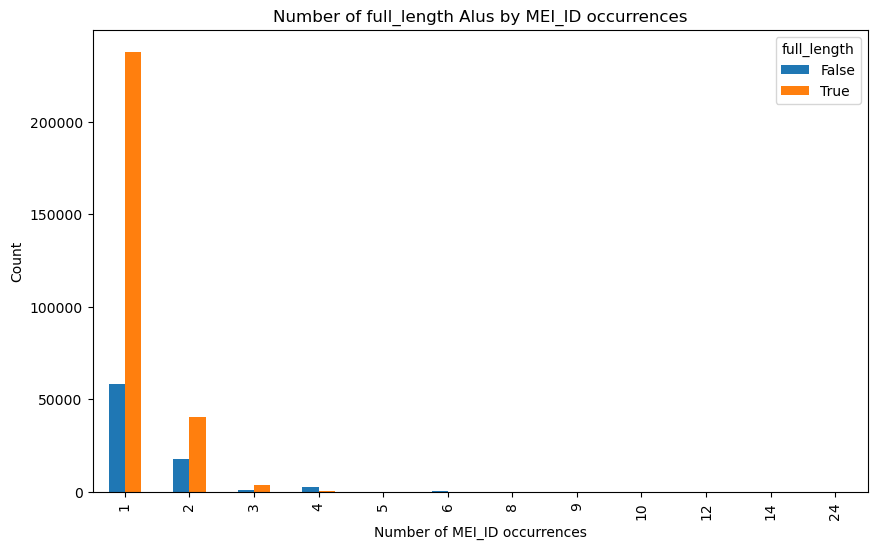

full_length,False,True
count,,
1,0.730971,0.842692
2,0.219357,0.142992
3,0.013441,0.013274
4,0.029379,0.000978
5,0.000088,0.000060
6,0.005497,0.000004
8,0.000791,0.000000
9,0.000301,0.000000
10,0.000075,0.000000


In [13]:
# plot the counts of MEI_ID by full_length
# Count the occurrences of MEI_ID grouped by full_length
mei_id_counts = full_truncated_labels.groupby('full_length').MEI_ID.value_counts()

# Create a DataFrame to count the number of MEI_ID occurrences
mei_id_occurrence = mei_id_counts.groupby(level=0).value_counts().unstack(level=0, fill_value=0)

# Plot the barplot
mei_id_occurrence.plot(kind='bar', figsize=(10, 6), title='Number of full_length Alus by MEI_ID occurrences')
plt.xlabel('Number of MEI_ID occurrences')
plt.ylabel('Count')
plt.legend(title='full_length', labels=['False', 'True'])
plt.show()

# print the normalized value counts for MEI occurences
# Normalize by the total counts in False and True categories
total_counts = mei_id_occurrence.sum(axis=0)
mei_id_normalized = mei_id_occurrence.div(total_counts, axis=1)
mei_id_normalized

<Axes: xlabel='STR_classification'>

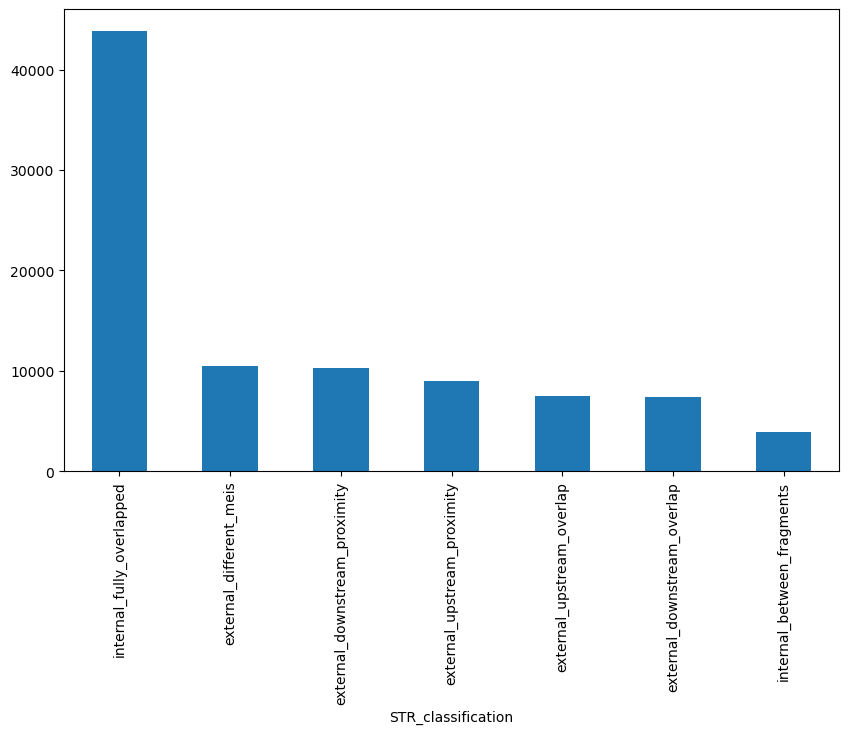

In [15]:
# for Alus annotated as not full_length (truncated) plot the distribution of STR_classification
truncated_labels = full_truncated_labels[full_truncated_labels["full_length"] == False]
fig, ax = plt.subplots(figsize=(10, 6))
truncated_labels.drop_duplicates(subset="LocusID")["STR_classification"].value_counts().plot(kind="bar", ax=ax)

## We want to include the following STRs in our position plots regarless of truncation status
1. internal_fully_overlapped
1. internal_between_fragments

Additionally, conditional on their position and terminal label we want to also include STRs labelled as 3' and external that map to the poly(A) tail

We can directly add the internal_fully_overlapped and poly(A) STRs to our full length plots, we need to rerun map positions on the internal_between_fragments with the merged Alu fragments -- these should also be checked if they are truncated

In [16]:
internal_fully_overlapped = truncated_labels[truncated_labels["STR_classification"] == "internal_fully_overlapped"]
print(f'There are {internal_fully_overlapped.shape[0]} Alus annotated as internal_fully_overlapped.')

# get the internal_between_fragments
internal_between_fragments = truncated_labels[truncated_labels["STR_classification"] == "internal_between_fragments"]
print(f'There are {internal_between_fragments.shape[0]} Alus annotated as internal_between_fragments.')


There are 51198 Alus annotated as internal_fully_overlapped.
There are 6837 Alus annotated as internal_between_fragments.


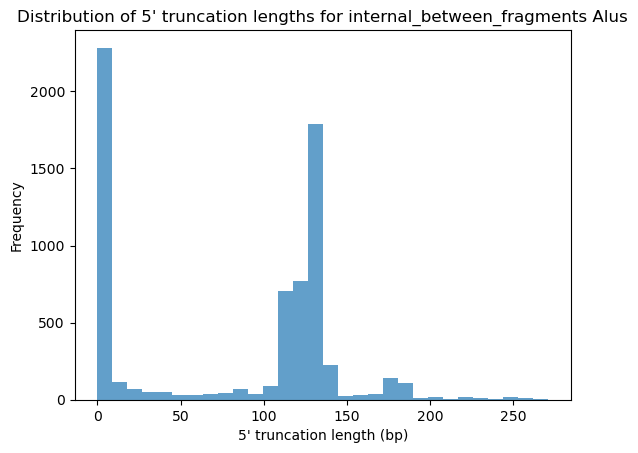

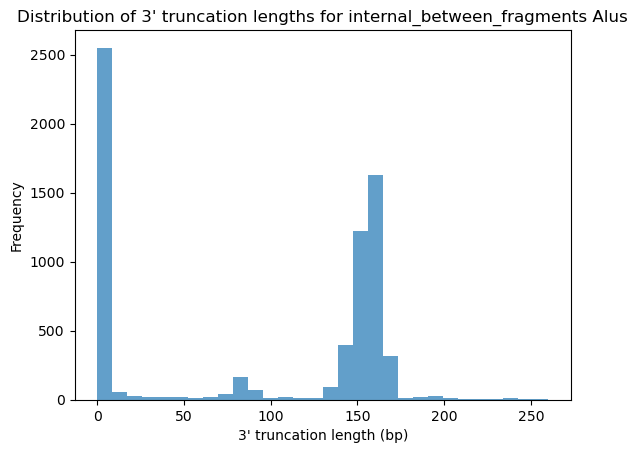

In [17]:
# what is the truncation lengths on the internal_between_fragments?
# plot the five_prime_truncation
internal_between_fragments["five_prime_truncation"].plot(kind="hist", bins=30, alpha=0.7)
plt.title("Distribution of 5' truncation lengths for internal_between_fragments Alus")
plt.xlabel("5' truncation length (bp)")
plt.ylabel("Frequency")
plt.show()

# 3 prime
internal_between_fragments["three_prime_truncation"].plot(kind="hist", bins=30, alpha=0.7)
plt.title("Distribution of 3' truncation lengths for internal_between_fragments Alus")
plt.xlabel("3' truncation length (bp)")
plt.ylabel("Frequency")
plt.show()


In [17]:
internal_between_fragments[internal_between_fragments.duplicated(subset="MEI_ID", keep=False)].sort_values(by=["MEI_ID","five_prime_truncation"])

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,orientation_alu,alu_subfamily,trunctation,five_prime_truncation,three_prime_truncation,full_length,query_sequence,query_begin,query_end,MEI_ID
68,chr1,396900,396941,476.0,464.0,396749,397059,SINE/Alu,AluSg,C,...,-,AluSg,0_162,0,162,False,chr1,396942,397059,464.0
69,chr1,396900,396941,476.0,464.0,396749,397059,SINE/Alu,AluSg,C,...,-,AluSg,156_0,156,0,False,chr1,396749,396901,464.0
310,chr1,1585289,1585318,2333.0,2011.0,1585117,1585468,SINE/Alu,AluSg,C,...,-,AluSg,129_0,129,0,False,chr1,1585117,1585290,2011.0
311,chr1,1585289,1585318,2333.0,2011.0,1585117,1585468,SINE/Alu,AluSg,C,...,-,AluSg,134_0,134,0,False,chr1,1585322,1585468,2011.0
332,chr1,1653824,1653863,2476.0,2113.0,1653702,1654035,SINE/Alu,AluSx,+,...,+,AluSx,0_155,0,155,False,chr1,1653702,1653825,2113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440093,chrY,26118122,26118136,4541036.0,4689886.0,26117822,26118160,SINE/Alu,AluSz,+,...,+,AluSz,112_147,112,147,False,chrY,26118137,26118160,4689886.0
440116,chrY,26241352,26241385,4541201.0,4690036.0,26241235,26241523,SINE/Alu,AluSz6,+,...,+,AluSz6,1_161,1,161,False,chrY,26241235,26241353,4690036.0
440115,chrY,26241352,26241385,4541201.0,4690036.0,26241235,26241523,SINE/Alu,AluSz6,+,...,+,AluSz6,133_16,133,16,False,chrY,26241392,26241523,4690036.0
440164,chrY,26459042,26459069,4541566.0,4690399.0,26458899,26459088,SINE/Alu,AluSx,+,...,+,AluSx,115_148,115,148,False,chrY,26459070,26459088,4690399.0


The majority of these Alus are split essentially in half / have the full 300 ish sequence in the fragments associated with the Alu

We should assign these as actually truncated and not so we can pass them to the right script

/tmp/ipykernel_3564473/535507455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_between_fragments["total_fragment_length"] = internal_between_fragments["query_end"] - internal_between_fragments["query_begin"]


<Axes: >

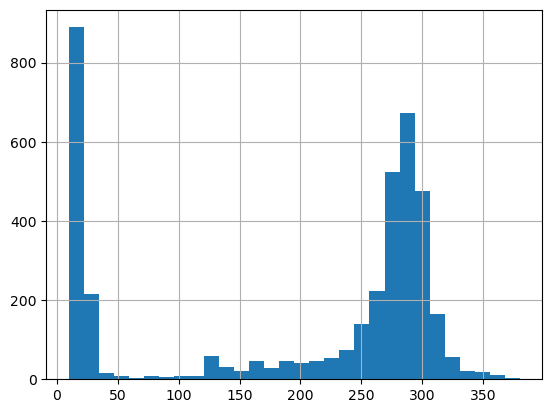

In [18]:
# get the total_fragment_length by getting all assigned meis to each LocusID and summing their length (end_mei - start_mei)
internal_between_fragments["total_fragment_length"] = internal_between_fragments["query_end"] - internal_between_fragments["query_begin"]
internal_between_fragments.groupby("LocusID")["total_fragment_length"].sum().hist(bins=30)

In [19]:
# labele the STRs (unique LocusIDs) to truncated and full length based on the summed fragment length -- if the summed fragment lengths are over 200, call these full length, else call them truncated
# get the combined fragment length column based on the grouby above
internal_between_fragments["combined_fragment_length"] = internal_between_fragments.groupby("LocusID")["total_fragment_length"].transform("sum")
internal_between_fragments["truncated"] = internal_between_fragments["combined_fragment_length"] <= 200

internal_between_fragments.truncated.value_counts()

/tmp/ipykernel_3564473/1731707455.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_between_fragments["combined_fragment_length"] = internal_between_fragments.groupby("LocusID")["total_fragment_length"].transform("sum")
/tmp/ipykernel_3564473/1731707455.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_between_fragments["truncated"] = internal_between_fragments["combined_fragment_length"] <= 200


truncated
False    5120
True     1717
Name: count, dtype: int64

In [57]:
# output a bed file of chrom start_mei end_mei for truncated and one for fulllength
internal_between_fragments["mei_id_bed"] = internal_between_fragments.mei_subfamily + "." + internal_between_fragments.chrom.astype(str) + ":" + internal_between_fragments.start_mei.astype(str) + "-" + internal_between_fragments.end_mei.astype(str)
# replace C in orientation with -
internal_between_fragments["orientation"] = internal_between_fragments["orientation"].replace("C", "-")
internal_between_fragments[internal_between_fragments["truncated"]][["chrom", "start_mei", "end_mei", "mei_id_bed", "mei_subfamily", "orientation"]].to_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_truncated.bed", sep="\t", header=False, index=False)
internal_between_fragments[~internal_between_fragments["truncated"]][["chrom", "start_mei", "end_mei", "mei_id_bed", "mei_subfamily", "orientation"]].to_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_full_length.bed", sep="\t", header=False, index=False)

# output the input for the position mapping script
internal_between_fragments[internal_between_fragments["truncated"]][["chrom", "start","end","LocusID","start_mei", "end_mei", "mei_id_bed", "mei_subfamily", "orientation"]].to_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_truncated_input.bed", sep="\t", header=False, index=False)

# add fake dist columns
full = internal_between_fragments[~internal_between_fragments["truncated"]]
full["dist"] = 0
full[["chrom", "start","end","LocusID","chrom","start_mei","end_mei", "mei_id_bed", "mei_subfamily", "orientation","dist"]].to_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_full_length_input.bed", sep="\t", header=False, index=False)


/tmp/ipykernel_3074540/410913776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_between_fragments["mei_id_bed"] = internal_between_fragments.mei_subfamily + "." + internal_between_fragments.chrom.astype(str) + ":" + internal_between_fragments.start_mei.astype(str) + "-" + internal_between_fragments.end_mei.astype(str)
/tmp/ipykernel_3074540/410913776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_between_fragments["orientation"] = internal_between_fragments["orientation"].replace

In [22]:
internal_between_fragments[~internal_between_fragments["truncated"]]

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,five_prime_truncation,three_prime_truncation,full_length,query_sequence,query_begin,query_end,MEI_ID,total_fragment_length,combined_fragment_length,truncated
68,chr1,396900,396941,476.0,464.0,396749,397059,SINE/Alu,AluSg,C,...,0,162,False,chr1,396942,397059,464.0,117,269,False
69,chr1,396900,396941,476.0,464.0,396749,397059,SINE/Alu,AluSg,C,...,156,0,False,chr1,396749,396901,464.0,152,269,False
310,chr1,1585289,1585318,2333.0,2011.0,1585117,1585468,SINE/Alu,AluSg,C,...,129,0,False,chr1,1585117,1585290,2011.0,173,319,False
311,chr1,1585289,1585318,2333.0,2011.0,1585117,1585468,SINE/Alu,AluSg,C,...,134,0,False,chr1,1585322,1585468,2011.0,146,319,False
332,chr1,1653824,1653863,2476.0,2113.0,1653702,1654035,SINE/Alu,AluSx,+,...,0,155,False,chr1,1653702,1653825,2113.0,123,294,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440015,chrY,25530164,25530199,4540117.0,4689262.0,25530038,25530350,SINE/Alu,AluJr4,+,...,132,0,False,chrY,25530200,25530350,4689262.0,150,263,False
440078,chrY,26001004,26001031,4540880.0,4689776.0,26000868,26001205,SINE/Alu,AluSq2,+,...,1,155,False,chrY,26000868,26000992,4689776.0,124,297,False
440079,chrY,26001004,26001031,4540880.0,4689776.0,26000868,26001205,SINE/Alu,AluSq2,+,...,120,0,False,chrY,26001032,26001205,4689776.0,173,297,False
440115,chrY,26241352,26241385,4541201.0,4690036.0,26241235,26241523,SINE/Alu,AluSz6,+,...,133,16,False,chrY,26241392,26241523,4690036.0,131,249,False


In [20]:
# try only using the upstream fragment in case the STR being included is throwing off the alignment

only_upstream_mei = internal_between_fragments[~internal_between_fragments["truncated"]]
# separate by orientation
only_upstream_mei_pos = only_upstream_mei[only_upstream_mei["orientation"] == "+"]
only_upstream_mei_neg = only_upstream_mei[only_upstream_mei["orientation"] == "C"]

#for + orientation, sort by query_begin and replace start_mei with query_begin and end_mei with query_end
only_upstream_mei_pos = only_upstream_mei_pos.sort_values("query_begin").drop_duplicates(subset=["LocusID", "MEI_ID"], keep="first")
only_upstream_mei_pos["start_mei"] = only_upstream_mei_pos["query_begin"]
only_upstream_mei_pos["end_mei"] = only_upstream_mei_pos["query_end"]

# for - sort by query_begin but in descending order
only_upstream_mei_neg = only_upstream_mei_neg.sort_values("query_begin", ascending=False).drop_duplicates(subset=["LocusID", "MEI_ID"], keep="first")
only_upstream_mei_neg["start_mei"] = only_upstream_mei_neg["query_begin"]
only_upstream_mei_neg["end_mei"] = only_upstream_mei_neg["query_end"]

only_upstream_mei_neg

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,five_prime_truncation,three_prime_truncation,full_length,query_sequence,query_begin,query_end,MEI_ID,total_fragment_length,combined_fragment_length,truncated
37725,chr1,245959123,245959144,362330.0,374082.0,245959164,245959261,SINE/Alu,AluSz6,C,...,0,184,False,chr1,245959164,245959261,374082.0,97,316,False
37685,chr1,245586157,245586198,361784.0,373618.0,245586199,245586315,SINE/Alu,AluJr4,C,...,3,155,False,chr1,245586199,245586315,373618.0,116,286,False
37569,chr1,245205835,245205860,361079.0,372960.0,245205865,245206037,SINE/Alu,AluJr4,C,...,0,107,False,chr1,245205865,245206037,372960.0,172,303,False
36961,chr1,242795318,242795355,356954.0,368787.0,242795357,242795481,SINE/Alu,AluSz,C,...,0,156,False,chr1,242795357,242795481,368787.0,124,280,False
36655,chr1,241182824,241182849,354355.0,366090.0,241182853,241182936,SINE/Alu,AluSx,C,...,36,161,False,chr1,241182853,241182936,366090.0,83,259,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,chr1,396900,396941,476.0,464.0,396942,397059,SINE/Alu,AluSg,C,...,0,162,False,chr1,396942,397059,464.0,117,269,False
240495,chr20,338576,338613,4049819.0,2304031.0,338625,338745,SINE/Alu,AluSx,C,...,0,160,False,chr20,338625,338745,2304031.0,120,281,False
178133,chr18,151323,151353,3820090.0,1719777.0,151354,151475,SINE/Alu,AluJr,C,...,0,160,False,chr18,151354,151475,1719777.0,121,276,False
381392,chr8,110637,110676,2082737.0,3864587.0,110677,110796,SINE/Alu,AluSg,C,...,0,160,False,chr8,110677,110796,3864587.0,119,271,False


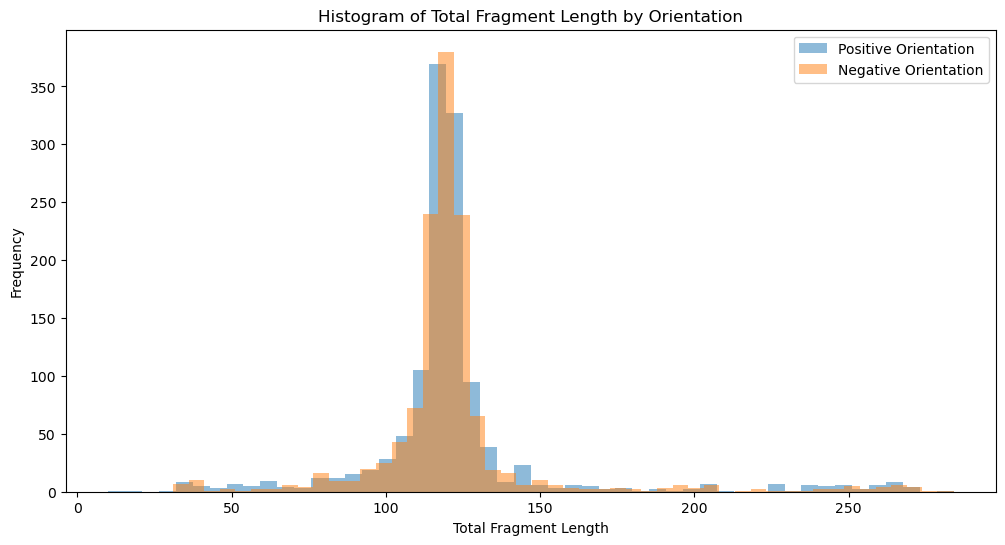

In [21]:
# plot the total_fragment_length columns as a histogram for both orientations
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(only_upstream_mei_pos["total_fragment_length"], bins=50, alpha=0.5, label="Positive Orientation")
plt.hist(only_upstream_mei_neg["total_fragment_length"], bins=50, alpha=0.5, label="Negative Orientation")
plt.xlabel("Total Fragment Length")
plt.ylabel("Frequency")
plt.title("Histogram of Total Fragment Length by Orientation")
plt.legend()
plt.show()

In [26]:
# Combine the positive and negative orientation dataframes
upstream_frag_only = pd.concat([only_upstream_mei_pos, only_upstream_mei_neg], ignore_index=True)
# add the mei_id_bed column based on the code above
upstream_frag_only["mei_id_bed"] = upstream_frag_only.mei_subfamily + "." + upstream_frag_only.chrom.astype(str) + ":" + upstream_frag_only.start_mei.astype(str) + "-" + upstream_frag_only.end_mei.astype(str)
upstream_frag_only["orientation"] = upstream_frag_only["orientation"].replace("C", "-")

# Save the combined dataframe to files with the label "upstream_frag_only"
upstream_frag_only[["chrom", "start_mei", "end_mei", "mei_id_bed", "mei_subfamily", "orientation"]].to_csv(
    "/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/upstream_frag_only.bed",
    sep="\t", header=False, index=False
)

upstream_frag_only["dist"] = 0
upstream_frag_only[["chrom", "start", "end", "LocusID",  "start_mei", "end_mei", "mei_id_bed", "mei_subfamily", "orientation"]].to_csv(
    "/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/upstream_frag_only_input.bed",
    sep="\t", header=False, index=False
)

In [25]:
upstream_frag_only.orientation == "-"

0       False
1       False
2       False
3       False
4       False
        ...  
2501     True
2502     True
2503     True
2504     True
2505     True
Name: orientation, Length: 2506, dtype: bool

In [23]:
upstream_frag_only

,chr,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,full_length,query_sequence,query_begin,query_end,MEI_ID,total_fragment_length,combined_fragment_length,truncated,mei_id_bed,dist
0,chr8,735310,735365,2083543.0,3865302.0,735178,735310,SINE/Alu,AluSc5,+,...,False,chr8,735178,735310,3865302.0,132,290,False,AluSc5.chr8:735178-735310,0
1,chr20,737623,737660,4050606.0,2304994.0,737494,737624,SINE/Alu,AluSq2,+,...,False,chr20,737494,737624,2304994.0,130,308,False,AluSq2.chr20:737494-737624,0
2,chr9,948902,948945,2300668.0,4111457.0,948779,948903,SINE/Alu,AluSx1,+,...,False,chr9,948779,948903,4111457.0,124,291,False,AluSx1.chr9:948779-948903,0
3,chr19,1191065,1191093,3934403.0,1831533.0,1190941,1191057,SINE/Alu,AluSx1,+,...,False,chr19,1190941,1191057,1831533.0,116,279,False,AluSx1.chr19:1190941-1191057,0
4,chr1,1653824,1653863,2476.0,2113.0,1653702,1653825,SINE/Alu,AluSx,+,...,False,chr1,1653702,1653825,2113.0,123,294,False,AluSx.chr1:1653702-1653825,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,chr1,396900,396941,476.0,464.0,396942,397059,SINE/Alu,AluSg,-,...,False,chr1,396942,397059,464.0,117,269,False,AluSg.chr1:396942-397059,0
2502,chr20,338576,338613,4049819.0,2304031.0,338625,338745,SINE/Alu,AluSx,-,...,False,chr20,338625,338745,2304031.0,120,281,False,AluSx.chr20:338625-338745,0
2503,chr18,151323,151353,3820090.0,1719777.0,151354,151475,SINE/Alu,AluJr,-,...,False,chr18,151354,151475,1719777.0,121,276,False,AluJr.chr18:151354-151475,0
2504,chr8,110637,110676,2082737.0,3864587.0,110677,110796,SINE/Alu,AluSg,-,...,False,chr8,110677,110796,3864587.0,119,271,False,AluSg.chr8:110677-110796,0


<Axes: ylabel='Frequency'>

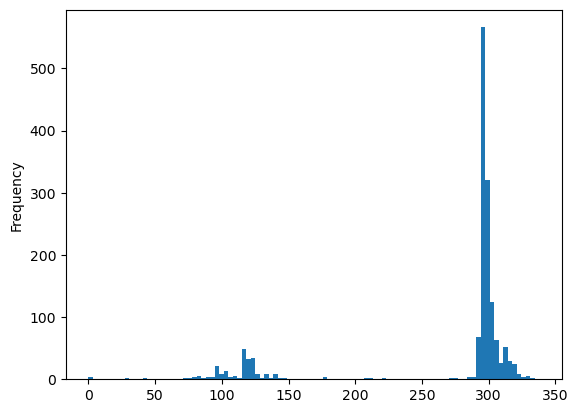

In [54]:
# read results and plot the positions
truncated_out = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_truncated_input_consensus_relative_start.txt", sep = "\t")
# plot a histogram of the consensus_relative_start columns
truncated_out['consensus_relative_start'].plot(kind='hist',bins = 100)

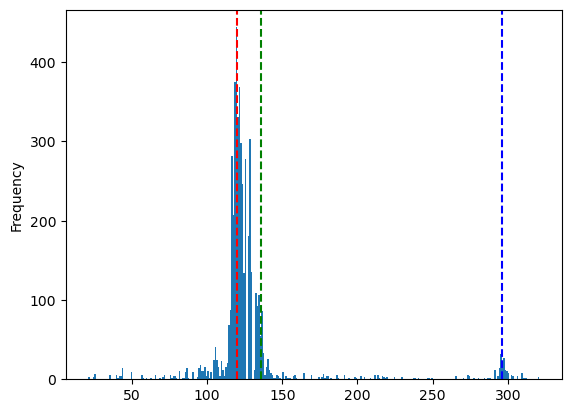

In [60]:
full_out = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_full_length_input_consensus_relative_start.txt", sep = "\t")
full_out['consensus_relative_start'].plot(kind='hist',bins = 300)
# plot verticle lines at 120 and 136 as well as 296
plt.axvline(x=120, color='r', linestyle='--')
plt.axvline(x=136, color='g', linestyle='--')
plt.axvline(x=296, color='b', linestyle='--')